In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/cmi-detect-behavior-with-sensor-data/train_demographics.csv
/kaggle/input/cmi-detect-behavior-with-sensor-data/test_demographics.csv
/kaggle/input/cmi-detect-behavior-with-sensor-data/train.csv
/kaggle/input/cmi-detect-behavior-with-sensor-data/test.csv
/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation/cmi_inference_server.py
/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation/cmi_gateway.py
/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation/__init__.py
/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation/core/templates.py
/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation/core/base_gateway.py
/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation/core/relay.py
/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation/core/kaggle_evaluation.proto
/kaggle/input/cmi-detect-behavior-with-sensor-data/kaggle_evaluation/core/__init__.py
/kaggle/input/cmi-detect-behav

EDA - exploratory data analysis

In [2]:
dataset = pd.read_csv('/kaggle/input/cmi-detect-behavior-with-sensor-data/train.csv')

In [72]:
dataset.shape

(574945, 342)

In [71]:
null_counts = dataset.isnull().sum()
columns_with_nulls = null_counts[null_counts > 0]
print(columns_with_nulls)

rot_w         3692
rot_x         3692
rot_y         3692
rot_z         3692
thm_1         6987
             ...  
tof_5_v59    30142
tof_5_v60    30142
tof_5_v61    30142
tof_5_v62    30142
tof_5_v63    30142
Length: 329, dtype: int64


In [ ]:
dataset.head()

In [ ]:
np.unique(dataset['behavior'])

In [ ]:
np.unique(dataset['orientation'])

In [ ]:
np.unique(dataset['phase'])

In [ ]:
np.unique(dataset['gesture'])

In [3]:
target_gestures = {
    'Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair',
    'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch',
    'Neck - pinch skin', 'Neck - scratch', 'Pinch knee/leg skin',
    'Scratch knee/leg skin'
}

# Set output to 1 if gesture is in target list, otherwise 0
dataset['output'] = dataset['gesture'].isin(target_gestures).astype(int)


In [4]:
# relation between gesture and orientation
target_gestures = {
    'Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair',
    'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch',
    'Neck - pinch skin', 'Neck - scratch', 'Pinch knee/leg skin',
    'Scratch knee/leg skin'
}
filtered = dataset[dataset['gesture'].isin(target_gestures)]
unique_orientations = filtered['orientation'].unique()

print("Unique orientations for target gestures:")
print(unique_orientations)
print(dataset['orientation'].unique())

Unique orientations for target gestures:
['Seated Lean Non Dom - FACE DOWN' 'Lie on Side - Non Dominant'
 'Lie on Back' 'Seated Straight']
['Seated Lean Non Dom - FACE DOWN' 'Lie on Side - Non Dominant'
 'Seated Straight' 'Lie on Back']


In [5]:
# relation between gesture and behavior
target_gesture = {
    'Above ear - pull hair', 'Cheek - pinch skin', 'Eyebrow - pull hair',
    'Eyelash - pull hair', 'Forehead - pull hairline', 'Forehead - scratch',
    'Neck - pinch skin', 'Neck - scratch', 'Pinch knee/leg skin',
    'Scratch knee/leg skin'
}

filtered = dataset[dataset['gesture'].isin(target_gesture)]
filtered['behavior'].unique()

array(['Relaxes and moves hand to target location',
       'Hand at target location', 'Performs gesture',
       'Moves hand to target location'], dtype=object)

In [ ]:
np.unique(dataset['output'])

In [ ]:
np.unique(dataset['output'])

In [ ]:
print(dataset['gesture'][1], dataset['output'][1])    

In [ ]:
np.unique(dataset['sequence_type'])

In [6]:
T_seq = []
NT_seq = []
for ind, seq in enumerate(dataset['sequence_type']):
    if seq != 'Target':
        T_seq.append(dataset['gesture'][ind])
    else:
        NT_seq.append(dataset['gesture'][ind])
# print('Target_seq: ', np.unique(np.array(Target_seq)),'\n', 'NT_seq: ', np.unique(np.array(NT_seq)))
list(set(T_seq)-set(NT_seq))
list(set(NT_seq)-set(T_seq))

['Neck - scratch',
 'Eyelash - pull hair',
 'Forehead - pull hairline',
 'Cheek - pinch skin',
 'Neck - pinch skin',
 'Forehead - scratch',
 'Above ear - pull hair',
 'Eyebrow - pull hair']

In [ ]:
dataset.info()

In [ ]:
dataset.describe()

Correlation: -0.03


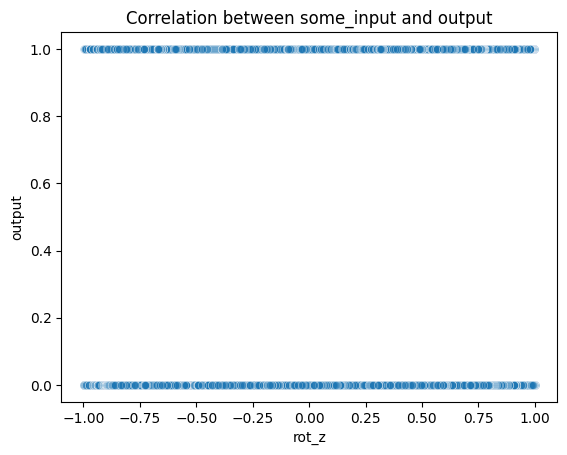

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation
correlation = dataset['rot_z'].corr(dataset['output'])
print(f'Correlation: {correlation:.2f}')

# Plot using seaborn
sns.scatterplot(data=dataset, x='rot_z', y='output', alpha=0.5)
plt.title('Correlation between some_input and output')
plt.show()

In [8]:
dataset_demo = pd.read_csv('/kaggle/input/cmi-detect-behavior-with-sensor-data/train_demographics.csv')

In [ ]:
dataset_demo.head()

In [9]:
# join both the datasets
merged_df = pd.merge(dataset, dataset_demo, on='subject', how='left')

In [ ]:
merged_df.head()

In [10]:
columns_of_interest = ['adult_child','age','sex','handedness','height_cm','shoulder_to_wrist_cm','elbow_to_wrist_cm']
correlations = merged_df[columns_of_interest + ['output']].corr(numeric_only=True)['output'].drop('output')
print(correlations)

adult_child            -0.002388
age                    -0.001403
sex                    -0.009721
handedness             -0.011761
height_cm               0.003526
shoulder_to_wrist_cm    0.002913
elbow_to_wrist_cm       0.001330
Name: output, dtype: float64


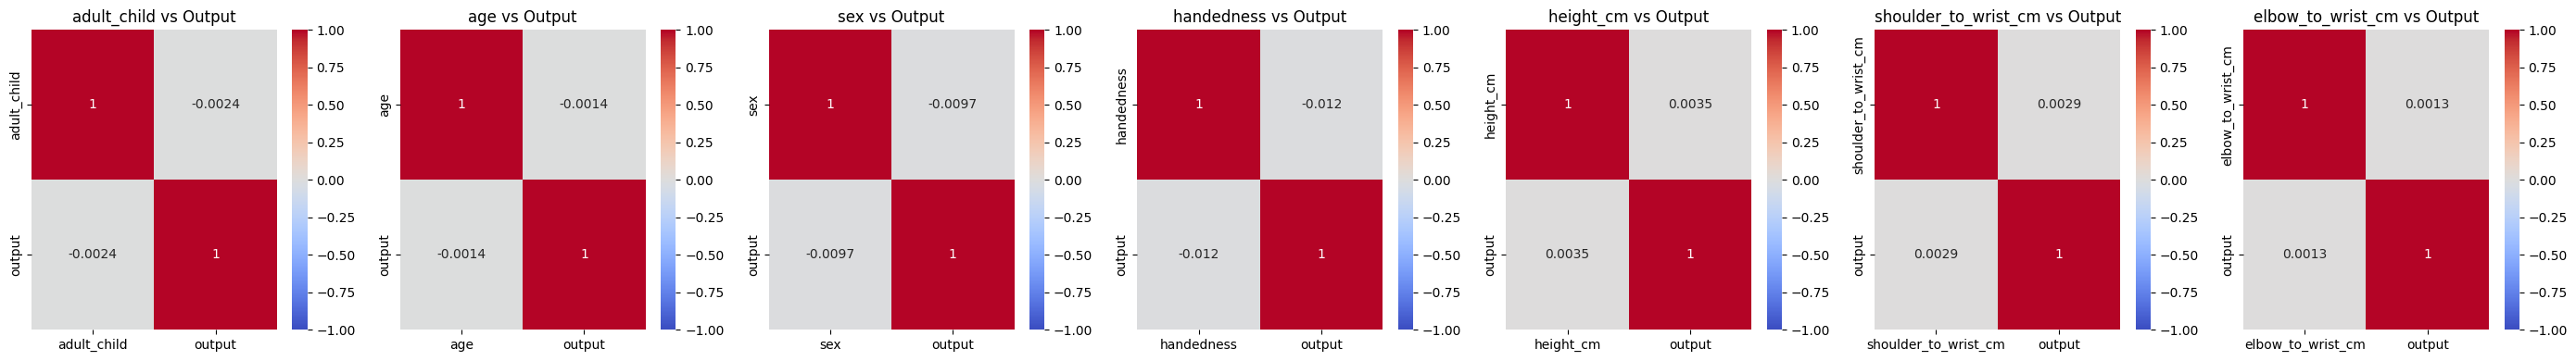

In [11]:
# Set up plot grid
fig, axes = plt.subplots(1, len(columns_of_interest), figsize=(4 * len(columns_of_interest), 4))

for i, col in enumerate(columns_of_interest):
    # Extract just the column and the output
    corr = merged_df[[col, 'output']].corr(numeric_only=True)
    
    # Draw heatmap for this pair
    sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, ax=axes[i])
    axes[i].set_title(f'{col} vs Output')

plt.tight_layout()
plt.show()

In [ ]:
# Compute the correlation matrix
# corr_matrix = merged_df.corr(numeric_only=True)

In [ ]:
# print(corr_matrix.head())

In [11]:
merged_df.columns

Index(['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject',
       'orientation', 'behavior', 'phase', 'gesture', 'acc_x',
       ...
       'tof_5_v62', 'tof_5_v63', 'output', 'adult_child', 'age', 'sex',
       'handedness', 'height_cm', 'shoulder_to_wrist_cm', 'elbow_to_wrist_cm'],
      dtype='object', length=349)

In [12]:
dataset.columns

Index(['row_id', 'sequence_type', 'sequence_id', 'sequence_counter', 'subject',
       'orientation', 'behavior', 'phase', 'gesture', 'acc_x',
       ...
       'tof_5_v55', 'tof_5_v56', 'tof_5_v57', 'tof_5_v58', 'tof_5_v59',
       'tof_5_v60', 'tof_5_v61', 'tof_5_v62', 'tof_5_v63', 'output'],
      dtype='object', length=342)

In [10]:
tof_columns = []

for sensor in range(1, 6):  # Sensors 1 to 5
    for pixel in range(64):  # Pixels v0 to v63
        col_name = f"tof_{sensor}_v{pixel}"
        tof_columns.append(col_name)
print(tof_columns)

['tof_1_v0', 'tof_1_v1', 'tof_1_v2', 'tof_1_v3', 'tof_1_v4', 'tof_1_v5', 'tof_1_v6', 'tof_1_v7', 'tof_1_v8', 'tof_1_v9', 'tof_1_v10', 'tof_1_v11', 'tof_1_v12', 'tof_1_v13', 'tof_1_v14', 'tof_1_v15', 'tof_1_v16', 'tof_1_v17', 'tof_1_v18', 'tof_1_v19', 'tof_1_v20', 'tof_1_v21', 'tof_1_v22', 'tof_1_v23', 'tof_1_v24', 'tof_1_v25', 'tof_1_v26', 'tof_1_v27', 'tof_1_v28', 'tof_1_v29', 'tof_1_v30', 'tof_1_v31', 'tof_1_v32', 'tof_1_v33', 'tof_1_v34', 'tof_1_v35', 'tof_1_v36', 'tof_1_v37', 'tof_1_v38', 'tof_1_v39', 'tof_1_v40', 'tof_1_v41', 'tof_1_v42', 'tof_1_v43', 'tof_1_v44', 'tof_1_v45', 'tof_1_v46', 'tof_1_v47', 'tof_1_v48', 'tof_1_v49', 'tof_1_v50', 'tof_1_v51', 'tof_1_v52', 'tof_1_v53', 'tof_1_v54', 'tof_1_v55', 'tof_1_v56', 'tof_1_v57', 'tof_1_v58', 'tof_1_v59', 'tof_1_v60', 'tof_1_v61', 'tof_1_v62', 'tof_1_v63', 'tof_2_v0', 'tof_2_v1', 'tof_2_v2', 'tof_2_v3', 'tof_2_v4', 'tof_2_v5', 'tof_2_v6', 'tof_2_v7', 'tof_2_v8', 'tof_2_v9', 'tof_2_v10', 'tof_2_v11', 'tof_2_v12', 'tof_2_v13', 'tof_

In [11]:
cols = ['sequence_id','gesture','acc_x','acc_y','acc_z','rot_w','rot_x','rot_y','rot_z','thm_1','thm_2','thm_3','thm_4','thm_5','height_cm','shoulder_to_wrist_cm','elbow_to_wrist_cm']+tof_columns
print(len(cols))

337


In [12]:
filtered_df = merged_df[cols]
filtered_df.columns

Index(['sequence_id', 'gesture', 'acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x',
       'rot_y', 'rot_z', 'thm_1',
       ...
       'tof_5_v54', 'tof_5_v55', 'tof_5_v56', 'tof_5_v57', 'tof_5_v58',
       'tof_5_v59', 'tof_5_v60', 'tof_5_v61', 'tof_5_v62', 'tof_5_v63'],
      dtype='object', length=337)

In [13]:
res = [col for col in filtered_df.columns if 'gesture' in col]
print(res)

['gesture']


In [14]:
# Assuming 'df' is your DataFrame
group_columns = cols[:2]        # First two columns to group by
value_columns = cols[2:]        # The rest of the columns for mean
print(value_columns)

['acc_x', 'acc_y', 'acc_z', 'rot_w', 'rot_x', 'rot_y', 'rot_z', 'thm_1', 'thm_2', 'thm_3', 'thm_4', 'thm_5', 'height_cm', 'shoulder_to_wrist_cm', 'elbow_to_wrist_cm', 'tof_1_v0', 'tof_1_v1', 'tof_1_v2', 'tof_1_v3', 'tof_1_v4', 'tof_1_v5', 'tof_1_v6', 'tof_1_v7', 'tof_1_v8', 'tof_1_v9', 'tof_1_v10', 'tof_1_v11', 'tof_1_v12', 'tof_1_v13', 'tof_1_v14', 'tof_1_v15', 'tof_1_v16', 'tof_1_v17', 'tof_1_v18', 'tof_1_v19', 'tof_1_v20', 'tof_1_v21', 'tof_1_v22', 'tof_1_v23', 'tof_1_v24', 'tof_1_v25', 'tof_1_v26', 'tof_1_v27', 'tof_1_v28', 'tof_1_v29', 'tof_1_v30', 'tof_1_v31', 'tof_1_v32', 'tof_1_v33', 'tof_1_v34', 'tof_1_v35', 'tof_1_v36', 'tof_1_v37', 'tof_1_v38', 'tof_1_v39', 'tof_1_v40', 'tof_1_v41', 'tof_1_v42', 'tof_1_v43', 'tof_1_v44', 'tof_1_v45', 'tof_1_v46', 'tof_1_v47', 'tof_1_v48', 'tof_1_v49', 'tof_1_v50', 'tof_1_v51', 'tof_1_v52', 'tof_1_v53', 'tof_1_v54', 'tof_1_v55', 'tof_1_v56', 'tof_1_v57', 'tof_1_v58', 'tof_1_v59', 'tof_1_v60', 'tof_1_v61', 'tof_1_v62', 'tof_1_v63', 'tof_2_v0',

In [15]:
# Group by the first two columns and compute the mean of the others
grouped_mean = filtered_df.groupby(list(group_columns))[value_columns].mean().reset_index()
grouped_median = filtered_df.groupby(list(group_columns))[value_columns].median().reset_index()
# grouped_mean.to_excel('grouped_mean_output.xlsx', index=False)
# print(grouped_mean.head())
join_mean_median = pd.merge(grouped_mean,grouped_median, suffixes=('_mean','_median'),on=['sequence_id', 'gesture'])

In [35]:
join_mean_median.columns.size
# join_mean_median

672

In [44]:
res = [col for col in join_mean_median.columns if 'acc_x_mean' in col]
print(res)

['acc_x_mean']


In [38]:
# List of prefixes (base column names without suffix)
prefixes = [col[:-5] for col in join_mean_median.columns if col.endswith('_mean')]

for prefix in prefixes:
    mean_col = prefix + '_mean'
    median_col = prefix + '_median'
    status_col = prefix + '_status'  # New column to indicate equal or not

    # Calculate relative deviation, handle division by zero safely
    deviation = (join_mean_median[mean_col] - join_mean_median[median_col]).abs() / join_mean_median[median_col].replace(0, np.nan)

    # Mark 'equal' if deviation <= 0.05, else 'not equal'
    join_mean_median[status_col] = np.where(deviation <= 0.0, 'equal', 'not equal')

    # If median was zero, deviation is NaN, treat as 'not equal'
    join_mean_median[status_col].fillna('not equal', inplace=True)

/tmp/ipykernel_35/3548033813.py:16: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  join_mean_median[status_col].fillna('not equal', inplace=True)


In [39]:
join_mean_median.head()
join_mean_median.shape[0]

8151

In [67]:
status = [col for col in join_mean_median.columns if col.endswith('status')]
num = []
for ind, ele in enumerate(status):
    val = 100*join_mean_median[status[ind]].isin(['equal']).sum()/join_mean_median.shape[0]
    num.append(val)
# print(num)
data = {
    'status':status,
    'percentage_equal':num
}
df_status = pd.DataFrame(data)
df_status.head()
df_status.shape

(335, 2)

In [66]:
df_status[df_status['percentage_equal']>50].count()

status              219
percentage_equal    219
dtype: int64